# Fitts' Law

In this notebook we look at Fitts' Law as an example of a model of user behaviour, based on interaction data.

## Learning goals
 * Understanding an example model; insight into the original experiment by Fitts.
 * Knowing how to analyse similar interaction data yourself (e.g. for other UIs, interaction techniques and devices that you might work on in the future).

## Overview
Remember the key idea of Fitts' Law from the lecture: *The movement time for a user to reach a target (e.g. with a finger on a touchscreen) depends on distance and target size.* 

Formally, Fitts' Law describes this as a regression model (i.e. a line): 
$$MT = a + b\cdot ID = a + b \log_2{\left ( \frac{2D}{W} \right )}$$

Therein, $a, b$ are the line's parameter (intercept and slope). $MT$ is the movement time, $ID$ is the index of difficulty, $D$ is the distance from the start to the target cetnre, and $W$ is the target's width.

## The experiment
Paul Fitts examined this in an experiment with people: The participants had to repeatedly tap on two metal plates with a pen. 

**Quelle:** Fitts, P. M. (1954). The information capacity of the human motor system in controlling the amplitude of movement. *Journal of Experimental Psychology*, 47(6), 381–391. https://doi.org/10.1037/h0055392 


<div style="font-weight: bold; text-align: center; margin: 2em auto; max-width: 600px">
<img src="imgs/fitts_experiment.png" style="padding-bottom: 1em; max-width: 600px"/>
The experiment by Paul Fitts from 1954. This notebook examines the original data.
</div>




## Setup

Here we load some packages and the dataset.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
sns.set_style('whitegrid')
sns.set_context('notebook')

Overview of the dataset (compare to the figure):
 * There are four different target width values (W).
 * There are four different distances (D).
 * Fitts also compared two different pens (1oz und 1lb).
 * For each combination of width, distance and pen the dataset contains the mean movement time (MT), averaged over all participants.

In [3]:
data = pd.read_csv('data/fitts_original_data.csv')
data

,W,D,MT1oz,MT1lb
0,0.25,2,0.392,0.406
1,0.25,4,0.484,0.510
2,0.25,8,0.580,0.649
3,0.25,16,0.731,0.781
4,0.50,2,0.281,0.281
5,0.50,4,0.372,0.370
6,0.50,8,0.469,0.485
7,0.50,16,0.595,0.641
8,1.00,2,0.212,0.215
9,1.00,4,0.260,0.273


# Visualising the data

The following plots show this dataset, similar to the lecture. We focus on one pen (1oz) here.

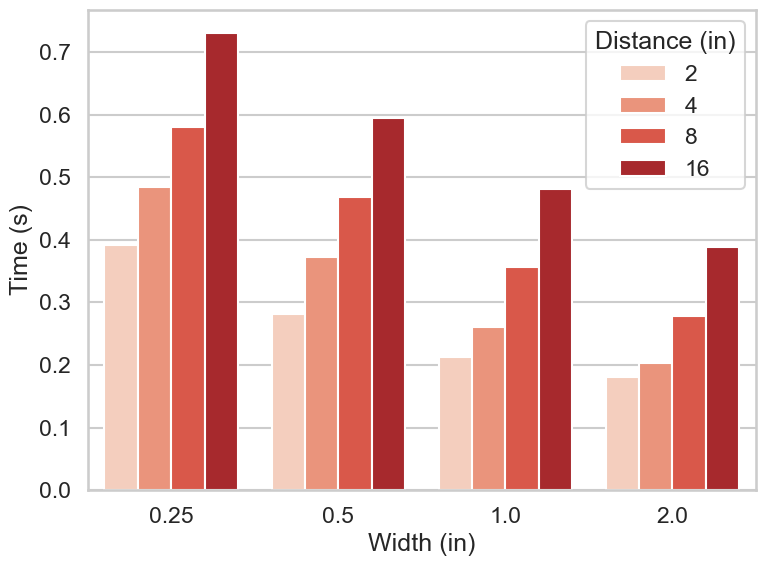

In [4]:
sns.set_context('talk')
plt.figure(figsize=(8, 6))
sns.barplot(x='W', y='MT1oz', hue='D', data=data, palette='Reds')
plt.ylabel('Time (s)')
plt.xlabel('Width (in)')
plt.gca().legend().set_title('Distance (in)')
plt.tight_layout()
plt.savefig('plot_fitts_data.png', dpi=300)
plt.show()

You can spot two trends (also see lecture):
   * Larger targets are faster to reach.
   * Targets that are further away are slower to reach.

# Computing the index of difficulty

Following Fitts' formula we compute the IDs as:

$$ ID=\log_2{\left ( \frac{2D}{W} \right )}$$

In [5]:
data['ID'] = np.log2(2*data['D']/data['W'])
data

,W,D,MT1oz,MT1lb,ID
0,0.25,2,0.392,0.406,4.0
1,0.25,4,0.484,0.510,5.0
2,0.25,8,0.580,0.649,6.0
3,0.25,16,0.731,0.781,7.0
4,0.50,2,0.281,0.281,3.0
5,0.50,4,0.372,0.370,4.0
6,0.50,8,0.469,0.485,5.0
7,0.50,16,0.595,0.641,6.0
8,1.00,2,0.212,0.215,2.0
9,1.00,4,0.260,0.273,3.0


In the lecture, we've seen an alternative definition of ID, the so called "Shannon formulation" by MacKenzie: 
$$ ID=\log_2{\left ( 1+ \frac{D}{W} \right )} $$

<p>
<div class="alert alert-block alert-success"> 
<h3>Optional task: Alternative IDs</h3> 
<br>
Adjust the computation above such that the Shannon version is computed. Compare the following analyses and plots between the two versions.
</div>
</p>

# Visualising the data using IDs
Now we can plot the data on a single axis (ID), instead of requiring axis and colour (for W and D, see above).

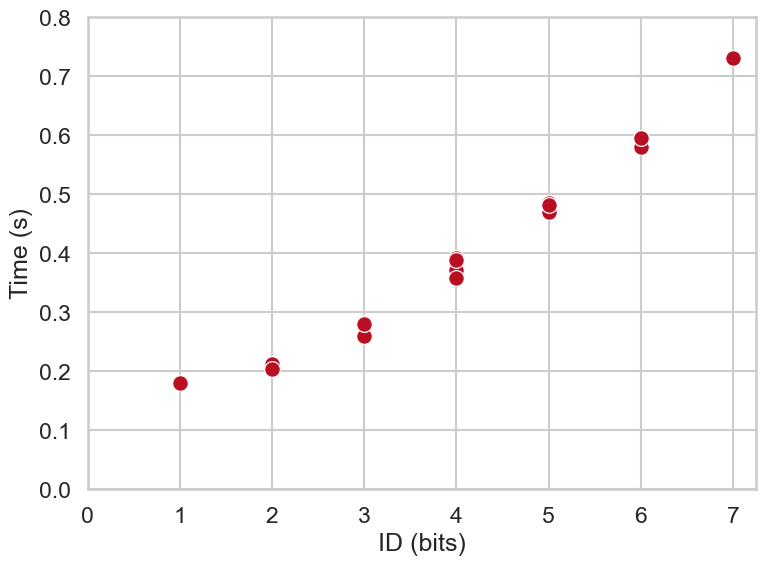

In [6]:
sns.set_context('talk')
plt.figure(figsize=(8, 6))
sns.scatterplot(x='ID', y='MT1oz', data=data, color='#B90F22', s=128)
plt.ylim(0, .8)
plt.xlim(0, 7.25)
plt.ylabel('Time (s)')
plt.xlabel('ID (bits)')
plt.tight_layout()
plt.savefig('plot_fitts_data_id.png', dpi=300)
plt.show()

This reveals a clear linear trend: More difficult targeting tasks take users more time.

# Applying linear regression

Now we can compute the paremeters $a$ and $b$, which describe the input device/technique (here: the pen).

Intuitively, $a$ corresponds to the reaction time (time it takes the user if the pen is already above the target, i.e. distance is 0), and $b$ is the additional time required for a task that is one bit more difficult than another task in comparison. Note that this is an intuitition but does not need to be always perfectly interpretable like that (e.g. linear regression can very well yield an $a$ < 0 but negative reaction time does not make much sense).

In [7]:
from sklearn.linear_model import LinearRegression

X, y = data['ID'].values.reshape(-1, 1), data['MT1oz'].values.reshape(-1, 1)
reg = LinearRegression().fit(X, y)
X_ext = np.vstack((np.zeros((1,1)), X))
preds = reg.predict(X_ext)

print('MT = %.2f + %.2f * ID' % (reg.intercept_, reg.coef_))

MT = 0.01 + 0.09 * ID


We can also plot this regression model / line:

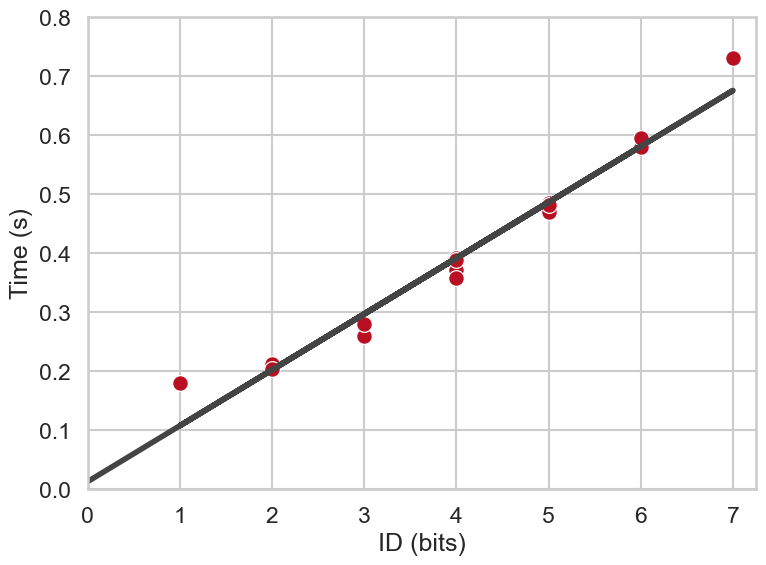

In [8]:
sns.set_context('talk')
plt.figure(figsize=(8, 6))
sns.scatterplot(x='ID', y='MT1oz', data=data, color='#B90F22', s=128)
plt.ylim(0, .8)
plt.xlim(0, 7.25)
plt.ylabel('Time (s)')
plt.xlabel('ID (bits)')
plt.tight_layout()
plt.plot(X_ext, preds, color='#444444', lw=4)
plt.savefig('plot_fitts_data_id_with_line.png', dpi=300)
plt.show()

<p>
<div class="alert alert-block alert-success"> 
<h3>Task: Compare the two pens</h3> 
<br>
Compute the regression line for the other pen (you can copy the regression code and switch "MT1oz" to "MT1lb", then add both lines to the plot). Compare the two regression lines. Which pen is faster to use for difficult tasks, based on this analysis?
</div>
</p>

MT = 0.01 + 0.09 * ID
MT = -0.01 + 0.10 * ID


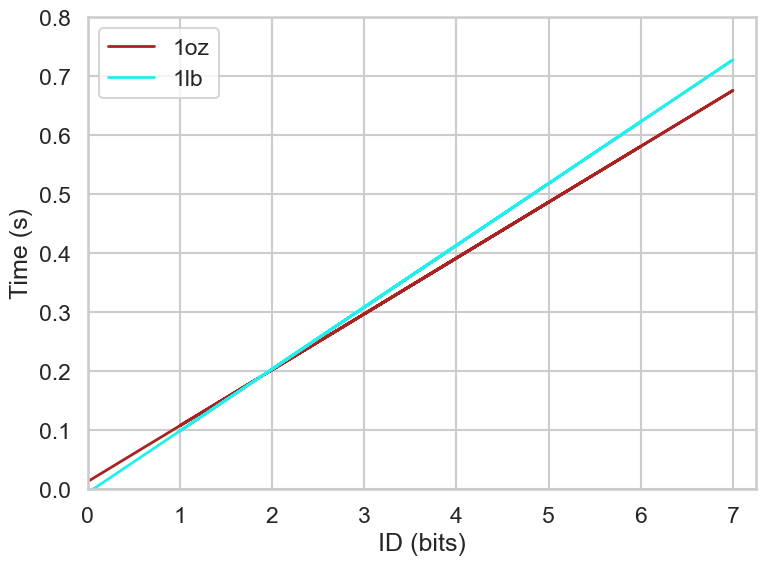

In [31]:
#TODO: compute regression for the other pen

sns.set_context('talk')
plt.figure(figsize=(8, 6))
plt.ylim(0, .8)
plt.xlim(0, 7.25)
plt.ylabel('Time (s)')
plt.xlabel('ID (bits)')
plt.tight_layout()
plt.plot(X_ext, preds, color='#aa2222', lw=2, label='1oz')
plt.plot(X_ext2, preds2, color='#22eeee', lw=2, label='1lb')
#plt.savefig('plot_fitts_data_id_with_line.png', dpi=300)
plt.legend()
plt.show()